# Module 5 Homework: Neural Networks

## Problem 1: Backpropagation by Hand (“pen and paper” → typed is preferred)

Consider a neural network with 2 inputs, a hidden layer with 2 neurons (sigmoid activation), and 1 output neuron (sigmoid activation). The weights are:

$$
W^{(1)} =
\begin{pmatrix}
0.5 & -0.3 \\
0.2 & 0.8
\end{pmatrix},
\quad
\mathbf{b}^{(1)} =
\begin{pmatrix}
0.1 \\
-0.1
\end{pmatrix}
$$

$$
\mathbf{w}^{(2)} =
\begin{pmatrix}
0.6 \\
-0.4
\end{pmatrix},
\quad
b^{(2)} = 0.2
$$

For input

$$
\mathbf{x} =
\begin{pmatrix}
1.0 \\
0.5
\end{pmatrix}
$$

with true label $y = 1$:

---

### (a) Forward Pass

Compute:

$$
z^{(1)}_1,\; z^{(1)}_2,\; h_1,\; h_2,\; z^{(2)},\; \hat{y}
$$

Show your work at each step.

---
#### Compute hidden layer pre-activation

$$
z^{(1)} = W^{(1)} \mathbf{x} + \mathbf{b}^{(1)}
$$

Compute each component:

$$
z^{(1)}_1 = 0.5 \cdot 1.0 + (-0.3) \cdot 0.5 + 0.1 = 0.5 - 0.15 + 0.1 = 0.45
$$

$$
z^{(1)}_2 = 0.2 \cdot 1.0 + 0.8 \cdot 0.5 + (-0.1) = 0.2 + 0.4 - 0.1 = 0.5
$$

$$
\boxed{ z^{(1)} =
\begin{pmatrix} 0.45 \\ 0.5 \end{pmatrix}}
$$

* Apply sigmoid activation to hidden layer (Sigmoid function: $ \sigma(z) = \frac{1}{1 + e^{-z}} $)

$$
h_1 = \sigma(0.45) = \frac{1}{1 + e^{-0.45}} \approx \boxed{0.6106}
$$

$$
h_2 = \sigma(0.5) = \frac{1}{1 + e^{-0.5}} \approx \boxed{0.6225}
$$

* Compute output pre-activation
$$
z^{(2)} = \mathbf{w}^{(2)\top} \mathbf{h} + b^{(2)}
$$

$$
z^{(2)} = 0.6 \cdot 0.6106 + (-0.4) \cdot 0.6225 + 0.2 \approx \boxed{0.317}
$$

* Apply sigmoid activation to output
$$
\hat{y} = \sigma(z^{(2)}) = \frac{1}{1 + e^{-0.317}} \approx \boxed{0.5786}
$$

---

### (b) Loss

Compute the binary cross-entropy loss for this single sample.

---
Binary cross-entropy loss:

$$
\mathcal{L} = -\left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
$$

Given:
- $y = 1$
- $\hat{y} \approx 0.5786$

Substitute:
$$
\mathcal{L} = -\left[ 1 \cdot \log(0.5786) + (1 - 1)\log(1 - 0.5786) \right]
$$

Simplify:

$$
\mathcal{L} = -\log(0.5786)
$$

Compute the value:
$$
\log(0.5786) \approx -0.547
$$

$$
\boxed{\mathcal{L} \approx 0.547}
$$

---

### (c) Backward Pass

Compute:

$$
\delta^{(2)},\quad
\frac{\partial L}{\partial \mathbf{w}^{(2)}},\quad
\frac{\partial L}{\partial b^{(2)}},\quad
\delta^{(1)},\quad
\frac{\partial L}{\partial W^{(1)}},\quad
\frac{\partial L}{\partial \mathbf{b}^{(1)}}
$$

---
For binary cross-entropy with sigmoid:

$$
\delta^{(2)} = \hat{y} - y
$$

$$
\boxed{\delta^{(2)} = 0.579 - 1 = -0.421}
$$

Gradients for output layer:
$$
\frac{\partial L}{\partial \mathbf{w}^{(2)}} = \delta^{(2)} \mathbf{h}
$$

$$
\frac{\partial L}{\partial w^{(2)}_1} = -0.421 \cdot 0.611 \approx -0.257
$$

$$
\frac{\partial L}{\partial w^{(2)}_2} = -0.421 \cdot 0.623 \approx -0.262
$$

$$
\boxed{
\frac{\partial L}{\partial \mathbf{w}^{(2)}} \approx
\begin{pmatrix}
-0.257 \\
-0.262
\end{pmatrix}
}
$$

Bias gradient:
$$
\boxed{
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)} = -0.421
}
$$

Hidden layer error
$$
\delta^{(1)} = (\mathbf{w}^{(2)} \delta^{(2)}) \odot \sigma'(z^{(1)})
$$

First compute:

$$
\mathbf{w}^{(2)} \delta^{(2)} =
\begin{pmatrix}
0.6 \\
-0.4
\end{pmatrix}
(-0.421)
=
\begin{pmatrix}
-0.253 \\
0.168
\end{pmatrix}
$$

Now compute sigmoid derivatives:
$$
\sigma'(0.45) = 0.611(1 - 0.611) \approx 0.238
$$

$$
\sigma'(0.5) = 0.623(1 - 0.623) \approx 0.235
$$

Thus:
$$
\delta^{(1)}_1 = -0.253 \cdot 0.238 \approx -0.0602
$$

$$
\delta^{(1)}_2 = 0.168 \cdot 0.235 \approx 0.0395
$$

$$
\boxed{
\delta^{(1)} \approx
\begin{pmatrix}
-0.0602 \\
0.0395
\end{pmatrix}
}
$$

Gradients for first layer weights:
$$
\frac{\partial L}{\partial W^{(1)}} = \delta^{(1)} \mathbf{x}^T
$$

Compute each entry:
$$
\frac{\partial L}{\partial W^{(1)}_{11}} = -0.0602 \cdot 1.0 = -0.0602
$$

$$
\frac{\partial L}{\partial W^{(1)}_{12}} = -0.0602 \cdot 0.5 = -0.0301
$$

$$
\frac{\partial L}{\partial W^{(1)}_{21}} = 0.0395 \cdot 1.0 = 0.0395
$$

$$
\frac{\partial L}{\partial W^{(1)}_{22}} = 0.0395 \cdot 0.5 = 0.0198
$$

$$
\boxed{
\frac{\partial L}{\partial W^{(1)}} \approx
\begin{pmatrix}
-0.0602 & -0.0301 \\
0.0395 & 0.0198
\end{pmatrix}
}
$$

Gradients for first layer bias
$$
\frac{\partial L}{\partial \mathbf{b}^{(1)}} = \delta^{(1)}
$$

$$
\boxed{
\frac{\partial L}{\partial \mathbf{b}^{(1)}} \approx
\begin{pmatrix}
-0.0602 \\
0.0395
\end{pmatrix}
}
$$

---

### (d) Update

If the learning rate is:

$$
\eta = 0.1
$$

write out the updated values of $\mathbf{w}^{(2)}$ and $b^{(2)}$ after one gradient descent step.

---

Gradient descent update rule:
$$
\theta_{\text{new}} = \theta_{\text{old}} - \eta \frac{\partial L}{\partial \theta}
$$

Update for $\mathbf{w}^{(2)}$
$$
\mathbf{w}^{(2)}_{\text{new}} = \mathbf{w}^{(2)} - \eta \frac{\partial L}{\partial \mathbf{w}^{(2)}}
$$

$$
=\begin{pmatrix}0.6 \\-0.4\end{pmatrix}-0.1
\begin{pmatrix}
-0.257 \\-0.262
\end{pmatrix}
$$

$$
=\begin{pmatrix}
0.6 + 0.0257 \\
-0.4 + 0.0262
\end{pmatrix}
=\begin{pmatrix}
0.626 \\
-0.374
\end{pmatrix}
$$

$$
\boxed{
\mathbf{w}^{(2)}_{\text{new}} \approx
\begin{pmatrix}
0.626 \\
-0.374
\end{pmatrix}
}
$$

Update for $b^{(2)}$
$$
b^{(2)}_{\text{new}} = b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}
$$

$$
= 0.2 - 0.1(-0.421)
= 0.2 + 0.0421
= 0.242
$$

$$
\boxed{b^{(2)}_{\text{new}} \approx 0.242}
$$

---

### (e) Interpretation

Briefly explain:

- Why is it called “backpropagation”?  
- What is being propagated, and in what direction?

---
It's called backpropagation because errors are propagated backward through the network from the output layer to earlier layers. The quantity being propagated is the gradient of the loss with respect to each neuron’s pre-activation (the $\delta$ terms). This propagation follows the chain rule, allowing us to compute how each weight contributes to the final error. 

The direction is from the output layer back to the input layer, opposite the forward pass.

----

## Problem 4: Regression with a Neural Network

Neural networks are not just classifiers — they can also perform regression. For regression, the output layer is linear (no activation) and the loss is mean squared error (MSE) instead of cross-entropy.

This is the same sine-wave curve fitting problem from Module 1, but solved with a neural network instead of a polynomial.

---

### Setup Code

```python
np.random.seed(42)
X = np.linspace(0, 1, 200).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + 0.2 * np.random.randn(200)

class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H), nn.ReLU(), nn.Linear(H, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
```

Train with Adam (learning rate $\sim 0.005$) for enough epochs that the loss converges (5000–10000 may be needed). If your fit looks like a triangle wave, you need more epochs.

---

### Tasks



#### (a)

Train networks with:

$$
H = 1,\; 5,\; 20,\; 100
$$

Plot the fitted curves for all four on a grid, overlaid on the data and the true sine function:

$$
y = \sin(2\pi X)
$$


Training model with H = 1
Training model with H = 5
Training model with H = 20
Training model with H = 100


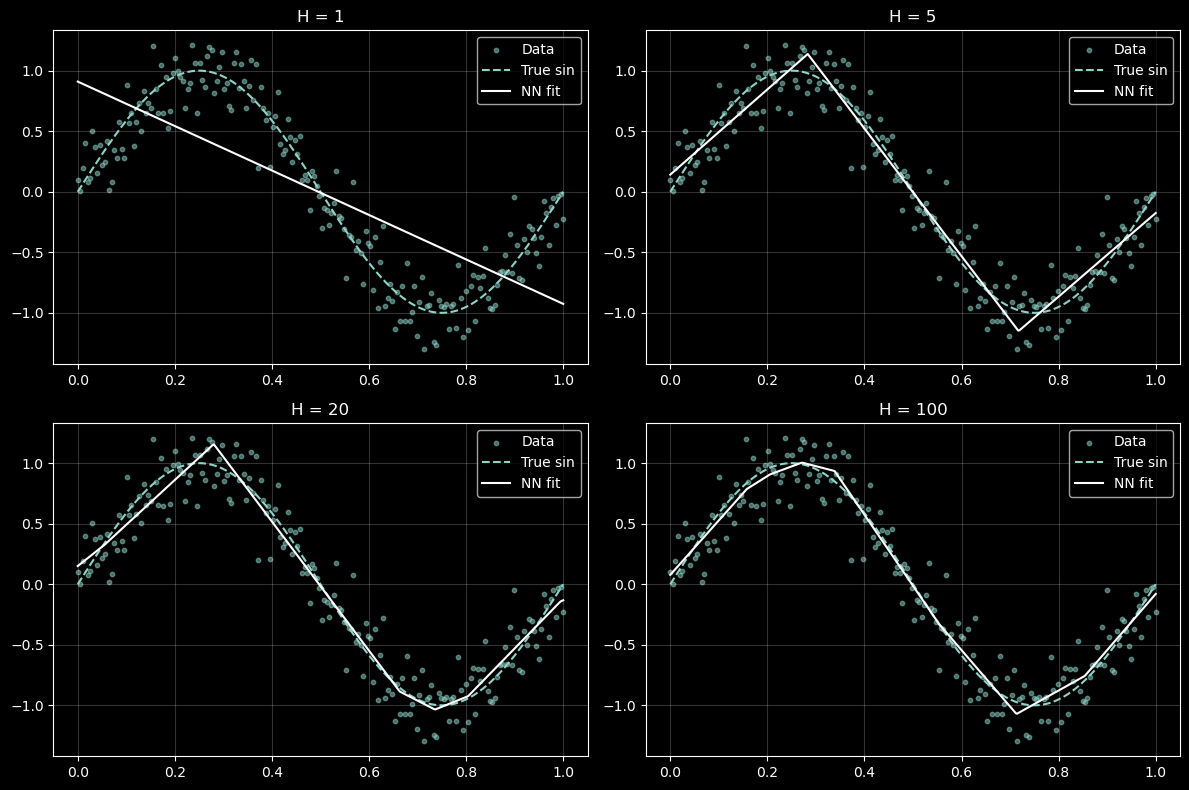

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
plt.style.use("dark_background")

##### SETUP CODE #####
# data
np.random.seed(42)
torch.manual_seed(42)

X = np.linspace(0, 1, 200).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + 0.2 * np.random.randn(200)

# model
class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H),
            nn.ReLU(),
            nn.Linear(H, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
##### SETUP CODE ######

# convert to torch tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)


# training function
def train_model(H, epochs=7000, lr=0.005):
    model = RegNet(H)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X_t)
        loss = loss_fn(y_pred, y_t)
        loss.backward()
        optimizer.step()

    return model

# train models
hidden_sizes = [1, 5, 20, 100]
models = {}

for H in hidden_sizes:
    print(f"Training model with H = {H}")
    models[H] = train_model(H)

# plotting
x_plot = np.linspace(0, 1, 400).reshape(-1, 1)
x_plot_t = torch.tensor(x_plot, dtype=torch.float32)
true_y = np.sin(2 * np.pi * x_plot)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, H in zip(axes.flatten(), hidden_sizes):
    model = models[H]
    with torch.no_grad():
        y_pred = model(x_plot_t).numpy()

    ax.scatter(X, y, s=10, alpha=0.5, label="Data")
    ax.plot(x_plot, true_y, '--', label="True sin")
    ax.plot(x_plot, y_pred, 'w', label="NN fit")

    ax.set_title(f"H = {H}")
    ax.grid(True, alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

#### (b) Discussion

Compare these results to the polynomial fits of different orders from Module 1.

In Module 1, a high-order polynomial overfits noisy data. Does the neural network with $H = 100$ overfit? If not, why might the network be more robust?

*Hint:* Think about the role of the activation function and the optimization procedure.

---

In Module 1, the high-order polynomials overfit because they are global functions, so fitting noise caused large oscillations everywhere. 

This neural network uses ReLU activations, which produce a piecewise linear function with local “kinks”, making it less prone to global oscillations. In addition, training with Adam (gradient-based optimization) does not force an exact fit to the noisy data and instead tends to find a smoother solution.